# Gaussian linear regression: unbiased LOO by stratified path sampling

For each replicate, draw an index $i$ uniformly in $\{0,\ldots,n-1\}$ and estimate

$$
\log p(y_i \mid y_{-i}) = \int_0^1 \mathbb{E}_{\pi_{i,\lambda}}[\log p(y_i \mid \theta)]\,d\lambda,
$$

where $\pi_{i,0}(\theta)=p(\theta \mid y_{-i})$ and $\pi_{i,1}(\theta)=p(\theta \mid y)$. Multiplying by $n$ gives an unbiased estimator of the total LOO ELPD.


In [3]:
from src import *

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
np.random.seed(2026)


## Simulated Gaussian linear model


In [4]:
n, d = 40, 1
true_theta = np.array([2.5])
X_data = np.random.randn(n, d)
sigma2_noise = 0.4**2
y_data = X_data @ true_theta + np.random.normal(0, np.sqrt(sigma2_noise), size=n)

prior_mean = np.zeros(d)
prior_cov = np.eye(d) * 10.0
prior_precision = np.linalg.inv(prior_cov)

blr_path = BayesianLinearRegressionTempering(
    X_data,
    y_data,
    prior_mean,
    prior_cov,
    sigma2_noise,
)



## `LOO with path sampling`

The path is the geometric path between the leave-one-out posterior and the full posterior:

$$
\pi_{i,\lambda}(\theta) \propto p(\theta\mid y_{-i})^{1-\lambda}p(\theta\mid y)^\lambda.
$$

Equivalently, up to normalizing constants,

$$
\pi_{i,\lambda}(\theta) \propto p(\theta)\prod_{j\ne i}p(y_j\mid\theta)\,p(y_i\mid\theta)^\lambda.
$$


In [5]:
loo_index = np.random.randint(n)


def log_target0(theta):
    """Unnormalized log posterior without observation loo_index."""
    return blr_path.log_posterior_minus_i(theta, loo_index)


def log_target1(theta):
    """Unnormalized full log posterior."""
    return blr_path.log_posterior_full(theta)


def log_target_path(theta, path):
    """Geometric path between p(theta | y_-i) and p(theta | y)."""
    return blr_path.log_path(theta, path, loo_index)


def grad_log_target_path(theta):
    """Derivative in lambda of log_target_path(theta, lambda)."""
    return blr_path.log_likelihood_i(theta, loo_index)


loo_log_densities_exact, true_value = blr_path.exact_loo_elpd()
print(f"Exact conjugate LOO ELPD: {true_value:.6f}")


Exact conjugate LOO ELPD: -16.294155


In [ ]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 10
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

In [8]:
lambda_grid

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

Lambda grid: 100%|██████████| 21/21 [00:13<00:00,  1.53it/s]


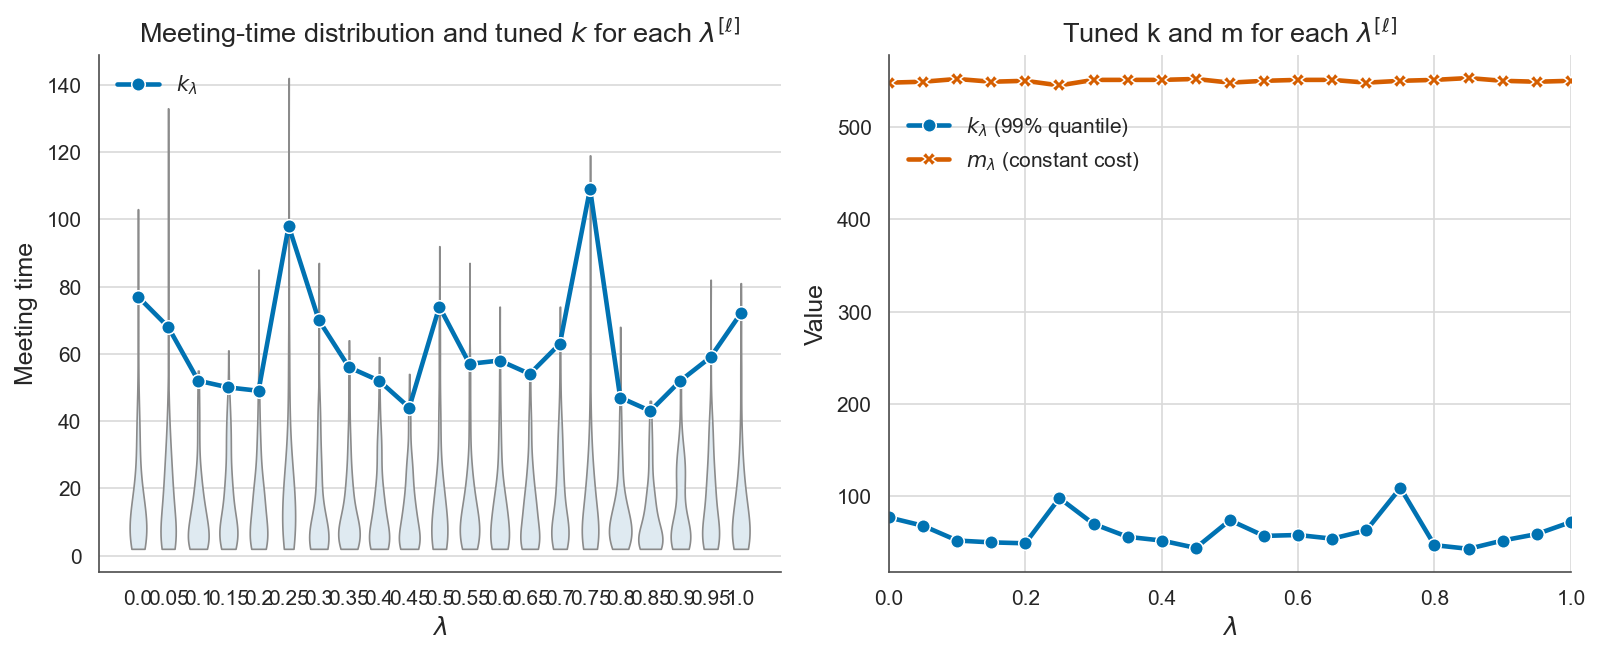

In [5]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

Final estimation: 100%|██████████| 21/21 [08:17<00:00, 23.67s/it]


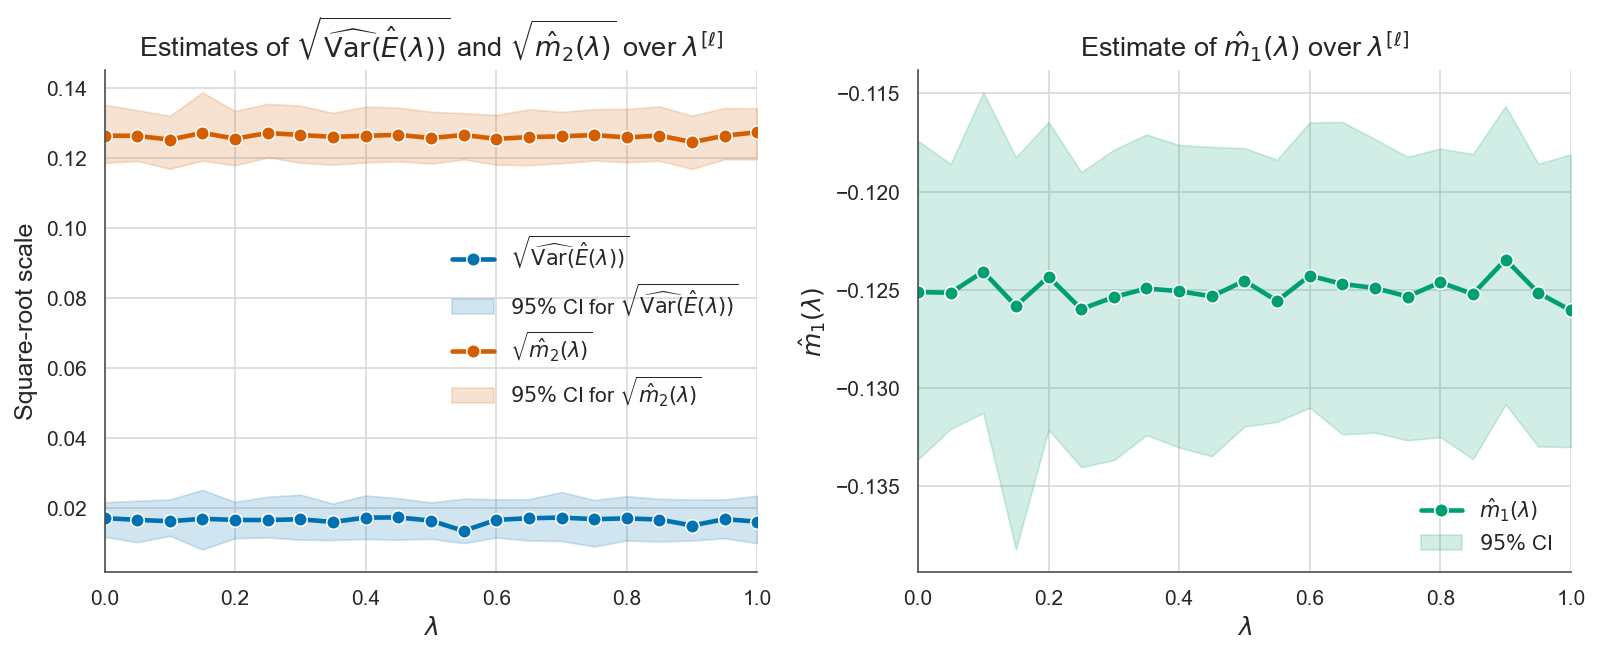

In [6]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

In [7]:
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)
sqrt_m2 = np.sqrt(np.maximum(res["m2"], 1e-12))

Final estimation:  86%|████████▌ | 18/21 [07:11<01:11, 23.96s/it]


KeyboardInterrupt: 

In [ ]:
M_grid = np.array([50, 100, 200]) # 500, 1000, 2000, 3000, 5000
for M in M_grid:

    estimates_opt = np.zeros(nrep)
    for _ in range(nrep):
        for i in range(M):

            st_loo =0

            loo_index = np.random.randint(n)
            log_target_path_i = lambda theta, path, i=loo_index: blr_path.log_path(theta, path, i)
            grad_log_target_path_i = lambda theta, i=loo_index: blr_path.log_likelihood_i(theta, i)
            estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path_i, grad_log_target_path_i)
            budget = build_budget(
            L=L,
            M=M,
            estimator=estimator_i,
            n_samples_per_bin=10,
        )
            st_loo += optimal_startified_estimator(L, estimator_i, budget)/M
        estimates_opt.append(st_loo)
plt.plot(M_grid, estimates_opt)
        








In [ ]:
M_grid = np.array([50, 100, 200])  # lambda budgets for each sampled LOO index
N_i = 20  # number of outer Monte Carlo draws over i
nrep_mse = 10
n_budget_pilot = 10

mean_estimates_is = np.zeros(len(M_grid))
mean_estimates_strat = np.zeros(len(M_grid))
mse_estimates_is = np.zeros(len(M_grid))
mse_estimates_strat = np.zeros(len(M_grid))


def make_loo_estimator(index_i):
    log_target_path_i = lambda theta, path, i=index_i: blr_path.log_path(
        theta,
        path,
        i,
    )

    grad_log_target_path_i = lambda theta, i=index_i: blr_path.log_likelihood_i(theta, i)

    return lambda lam: uestimator_given_lambda(
        lam,
        lambda_grid,
        k_grid,
        m_grid,
        sigmaq,
        lag,
        log_target_path_i,
        grad_log_target_path_i,
    )


for m_idx, M_lambda in enumerate(M_grid):
    estimates_is = np.zeros(nrep_mse)
    estimates_strat = np.zeros(nrep_mse)

    for r in range(nrep_mse):
        sampled_indices = np.random.randint(n, size=N_i)
        loo_integrals_is = np.zeros(N_i)
        loo_integrals_strat = np.zeros(N_i)

        for i_draw, index_i in enumerate(sampled_indices):
            estimator_i = make_loo_estimator(index_i)

            # Inner integral over lambda estimated by importance sampling.
            loo_integrals_is[i_draw] = q_unbiased_estimator(
                L,
                M_lambda,
                estimator_i,
                sqrt_m2,
            )

            # Inner integral over lambda estimated by stratified sampling,
            # using the same final lambda budget M_lambda.
            budget_i = build_budget(
                L=L,
                M=M_lambda,
                estimator=estimator_i,
                n_samples_per_bin=n_budget_pilot,
            )
            loo_integrals_strat[i_draw] = optimal_startified_estimator(
                L,
                estimator_i,
                budget_i,
            )

        # Outer expectation over I ~ Uniform({0, ..., n - 1}).
        estimates_is[r] = n * np.mean(loo_integrals_is)
        estimates_strat[r] = n * np.mean(loo_integrals_strat)

    mean_estimates_is[m_idx] = np.mean(estimates_is)
    mean_estimates_strat[m_idx] = np.mean(estimates_strat)
    mse_estimates_is[m_idx] = np.mean((estimates_is - true_value) ** 2)
    mse_estimates_strat[m_idx] = np.mean((estimates_strat - true_value) ** 2)

plt.figure(figsize=(7, 4.5), dpi=150)
plt.plot(M_grid, mse_estimates_is, marker="o", linewidth=2, label="Importance sampling")
plt.plot(M_grid, mse_estimates_strat, marker="o", linewidth=2, label="Stratified sampling")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lambda budget per sampled LOO index")
plt.ylabel("MSE")
plt.title("MSE comparison for Bayesian linear regression LOO")
plt.grid(True, which="both", alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "M_lambda": M_grid,
    "mean_is": mean_estimates_is,
    "mse_is": mse_estimates_is,
    "mean_stratified": mean_estimates_strat,
    "mse_stratified": mse_estimates_strat,
})
